In [ ]:
from google.colab import files
uploaded = files.upload()


Saving covid_19_india.csv to covid_19_india.csv
Saving covid_vaccine_statewise.csv to covid_vaccine_statewise.csv
Saving StatewiseTestingDetails.csv to StatewiseTestingDetails.csv


In [ ]:
import pandas as pd
import seaborn as sns

covid_data = pd.read_csv('covid_19_india.csv')
print(covid_data.head())
print()
covid_data.columns

   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  



Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')

In [ ]:
vaccine_data = pd.read_csv('covid_vaccine_statewise.csv')
print(vaccine_data.head())
print()
vaccine_data.columns

   Updated On  State  Total Doses Administered  Sessions   Sites   \
0  16/01/2021  India                   48276.0    3455.0   2957.0   
1  17/01/2021  India                   58604.0    8532.0   4954.0   
2  18/01/2021  India                   99449.0   13611.0   6583.0   
3  19/01/2021  India                  195525.0   17855.0   7951.0   
4  20/01/2021  India                  251280.0   25472.0  10504.0   

   First Dose Administered  Second Dose Administered  \
0                  48276.0                       0.0   
1                  58604.0                       0.0   
2                  99449.0                       0.0   
3                 195525.0                       0.0   
4                 251280.0                       0.0   

   Male (Doses Administered)  Female (Doses Administered)  \
0                        NaN                          NaN   
1                        NaN                          NaN   
2                        NaN                          NaN   
3   

Index(['Updated On', 'State', 'Total Doses Administered', 'Sessions',
       ' Sites ', 'First Dose Administered', 'Second Dose Administered',
       'Male (Doses Administered)', 'Female (Doses Administered)',
       'Transgender (Doses Administered)', ' Covaxin (Doses Administered)',
       'CoviShield (Doses Administered)', 'Sputnik V (Doses Administered)',
       'AEFI', '18-44 Years (Doses Administered)',
       '45-60 Years (Doses Administered)', '60+ Years (Doses Administered)',
       '18-44 Years(Individuals Vaccinated)',
       '45-60 Years(Individuals Vaccinated)',
       '60+ Years(Individuals Vaccinated)', 'Male(Individuals Vaccinated)',
       'Female(Individuals Vaccinated)', 'Transgender(Individuals Vaccinated)',
       'Total Individuals Vaccinated'],
      dtype='object')

In [ ]:
testing_data = pd.read_csv('StatewiseTestingDetails.csv')
print(testing_data.head())
print()
testing_data.columns

         Date                        State  TotalSamples Negative  Positive
0  2020-04-17  Andaman and Nicobar Islands        1403.0     1210      12.0
1  2020-04-24  Andaman and Nicobar Islands        2679.0      NaN      27.0
2  2020-04-27  Andaman and Nicobar Islands        2848.0      NaN      33.0
3  2020-05-01  Andaman and Nicobar Islands        3754.0      NaN      33.0
4  2020-05-16  Andaman and Nicobar Islands        6677.0      NaN      33.0



Index(['Date', 'State', 'TotalSamples', 'Negative', 'Positive'], dtype='object')

In [ ]:
# Display shapes and check for missing values in all datasets
covid_summary = {
    "shape": covid_data.shape,
    "missing_values": covid_data.isnull().sum()
}

covid_summary

{'shape': (18110, 9),
 'missing_values': Sno                         0
 Date                        0
 Time                        0
 State/UnionTerritory        0
 ConfirmedIndianNational     0
 ConfirmedForeignNational    0
 Cured                       0
 Deaths                      0
 Confirmed                   0
 dtype: int64}

In [ ]:
vaccine_summary = {
    "shape": vaccine_data.shape,
    "missing_values": vaccine_data.isnull().sum()
}

vaccine_summary

{'shape': (7845, 24),
 'missing_values': Updated On                                0
 State                                     0
 Total Doses Administered                224
 Sessions                                224
  Sites                                  224
 First Dose Administered                 224
 Second Dose Administered                224
 Male (Doses Administered)               384
 Female (Doses Administered)             384
 Transgender (Doses Administered)        384
  Covaxin (Doses Administered)           224
 CoviShield (Doses Administered)         224
 Sputnik V (Doses Administered)         4850
 AEFI                                   2407
 18-44 Years (Doses Administered)       6143
 45-60 Years (Doses Administered)       6143
 60+ Years (Doses Administered)         6143
 18-44 Years(Individuals Vaccinated)    4112
 45-60 Years(Individuals Vaccinated)    4111
 60+ Years(Individuals Vaccinated)      4111
 Male(Individuals Vaccinated)           7685
 Female(Individ

In [ ]:
testing_summary = {
    "shape": testing_data.shape,
    "missing_values": testing_data.isnull().sum()
}

testing_summary

{'shape': (16336, 5),
 'missing_values': Date                0
 State               0
 TotalSamples        0
 Negative         9367
 Positive        10674
 dtype: int64}

**Data Cleaning**

In [ ]:
covid_data['Date'] = pd.to_datetime(covid_data['Date'], format='%Y-%m-%d')
covid_data = covid_data.dropna()
covid_data = covid_data.rename(columns={'State/UnionTerritory': 'State'})
covid_data.head()

,Sno,Date,Time,State,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


In [ ]:
#print(vaccine_data.columns)
vaccine_data = vaccine_data.rename(columns={'Updated On': 'Date'})
vaccine_data['Date'] = pd.to_datetime(vaccine_data['Date'], format='%d/%m/%Y')
vaccine_data = vaccine_data.dropna(subset=['Total Individuals Vaccinated'])
vaccine_data.head()

,Date,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,2021-01-16,India,48276.0,3455.0,2957.0,48276.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23757.0,24517.0,2.0,48276.0
1,2021-01-17,India,58604.0,8532.0,4954.0,58604.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27348.0,31252.0,4.0,58604.0
2,2021-01-18,India,99449.0,13611.0,6583.0,99449.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41361.0,58083.0,5.0,99449.0
3,2021-01-19,India,195525.0,17855.0,7951.0,195525.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,81901.0,113613.0,11.0,195525.0
4,2021-01-20,India,251280.0,25472.0,10504.0,251280.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,98111.0,153145.0,24.0,251280.0


In [ ]:
testing_data['Date'] = pd.to_datetime(testing_data['Date'])
testing_data = testing_data.dropna()
testing_data.head()

,Date,State,TotalSamples,Negative,Positive
0,2020-04-17,Andaman and Nicobar Islands,1403.0,1210,12.0
453,2020-04-02,Andhra Pradesh,1800.0,1175,132.0
454,2020-04-10,Andhra Pradesh,6374.0,6009,365.0
455,2020-04-11,Andhra Pradesh,6958.0,6577,381.0
456,2020-04-12,Andhra Pradesh,6958.0,6553,405.0


**Summarization**

In [ ]:
covid_data.describe()

,Sno,Date,Cured,Deaths,Confirmed
count,18110.000000,18110,1.811000e+04,18110.000000,1.811000e+04
mean,9055.500000,2020-11-30 21:49:50.127001344,2.786375e+05,4052.402264,3.010314e+05
min,1.000000,2020-01-30 00:00:00,0.000000e+00,0.000000,0.000000e+00
25%,4528.250000,2020-07-26 00:00:00,3.360250e+03,32.000000,4.376750e+03
50%,9055.500000,2020-12-03 00:00:00,3.336400e+04,588.000000,3.977350e+04
75%,13582.750000,2021-04-08 00:00:00,2.788698e+05,3643.750000,3.001498e+05
max,18110.000000,2021-08-11 00:00:00,6.159676e+06,134201.000000,6.363442e+06
std,5228.051023,NaN,6.148909e+05,10919.076411,6.561489e+05


In [ ]:
vaccine_data.describe()

,Date,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),Covaxin (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
count,5919,5.919000e+03,5.919000e+03,5919.000000,5.919000e+03,5.919000e+03,5.759000e+03,5.759000e+03,5759.000000,5.919000e+03,...,0.0,0.0,0.0,3.733000e+03,3.734000e+03,3.734000e+03,1.600000e+02,1.600000e+02,160.000000,5.919000e+03
mean,2021-04-05 11:41:37.921946368,5.542652e+06,3.392782e+05,2374.682548,4.535770e+06,1.006882e+06,1.239029e+06,1.097209e+06,343.461191,5.801072e+05,...,NaN,NaN,NaN,1.395895e+06,2.916515e+06,2.627444e+06,4.461687e+07,3.951018e+07,12370.543750,4.547842e+06
min,2021-01-16 00:00:00,7.000000e+00,0.000000e+00,0.000000,7.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000,0.000000e+00,...,NaN,NaN,NaN,1.059000e+03,1.136000e+03,5.580000e+02,2.375700e+04,2.451700e+04,2.000000,7.000000e+00
25%,2021-02-24 12:00:00,8.610250e+04,3.800000e+03,70.000000,7.418750e+04,4.617000e+03,3.651200e+04,3.105850e+04,3.000000,0.000000e+00,...,NaN,NaN,NaN,5.655400e+04,9.248225e+04,5.615975e+04,5.739350e+06,5.023407e+06,1278.750000,7.427550e+04
50%,2021-04-05 00:00:00,4.591170e+05,2.010000e+04,614.000000,3.948220e+05,7.201400e+04,1.892690e+05,1.821030e+05,47.000000,3.178000e+03,...,NaN,NaN,NaN,2.947270e+05,8.330395e+05,7.887425e+05,3.716590e+07,3.365402e+07,8007.500000,4.022880e+05
75%,2021-05-15 00:00:00,4.175552e+06,2.321510e+05,1812.500000,3.501562e+06,6.392515e+05,1.655822e+06,1.428290e+06,422.500000,3.716175e+05,...,NaN,NaN,NaN,9.105160e+05,2.499280e+06,2.337874e+06,7.441663e+07,6.685368e+07,19851.000000,3.501562e+06
max,2021-06-24 00:00:00,3.034268e+08,3.501031e+07,73933.000000,2.506569e+08,5.276997e+07,1.422677e+07,1.104087e+07,6855.000000,3.613905e+07,...,NaN,NaN,NaN,9.224315e+07,9.096888e+07,6.731098e+07,1.349420e+08,1.156684e+08,46462.000000,2.506569e+08
std,NaN,2.258304e+07,1.397854e+06,7564.827665,1.833807e+07,4.297721e+06,2.077778e+06,1.794890e+06,645.499567,2.497604e+06,...,NaN,NaN,NaN,5.501454e+06,9.567607e+06,8.192225e+06,3.950749e+07,3.417684e+07,12485.026753,1.834182e+07


In [ ]:
testing_data.describe()

,Date,TotalSamples,Positive
count,3558,3.558000e+03,3.558000e+03
mean,2020-08-01 08:50:59.696458752,8.411734e+05,5.168392e+04
min,2020-04-01 00:00:00,5.800000e+01,0.000000e+00
25%,2020-05-15 06:00:00,1.960600e+04,4.322500e+02
50%,2020-06-26 00:00:00,1.247495e+05,3.184000e+03
75%,2020-08-20 18:00:00,6.004960e+05,3.347675e+04
max,2021-08-10 00:00:00,1.106613e+07,1.609516e+06
std,NaN,1.846544e+06,1.675987e+05


In [ ]:
covid_data.groupby('State')['Confirmed'].max().sort_values(ascending=False).head(10)

,Confirmed
State,
Maharashtra,6363442
Maharashtra***,6229596
Kerala,3586693
Karnataka,2921049
Karanataka,2885238
Tamil Nadu,2579130
Andhra Pradesh,1985182
Uttar Pradesh,1708812
West Bengal,1534999


<ipython-input-34-78de3ae438ba>:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


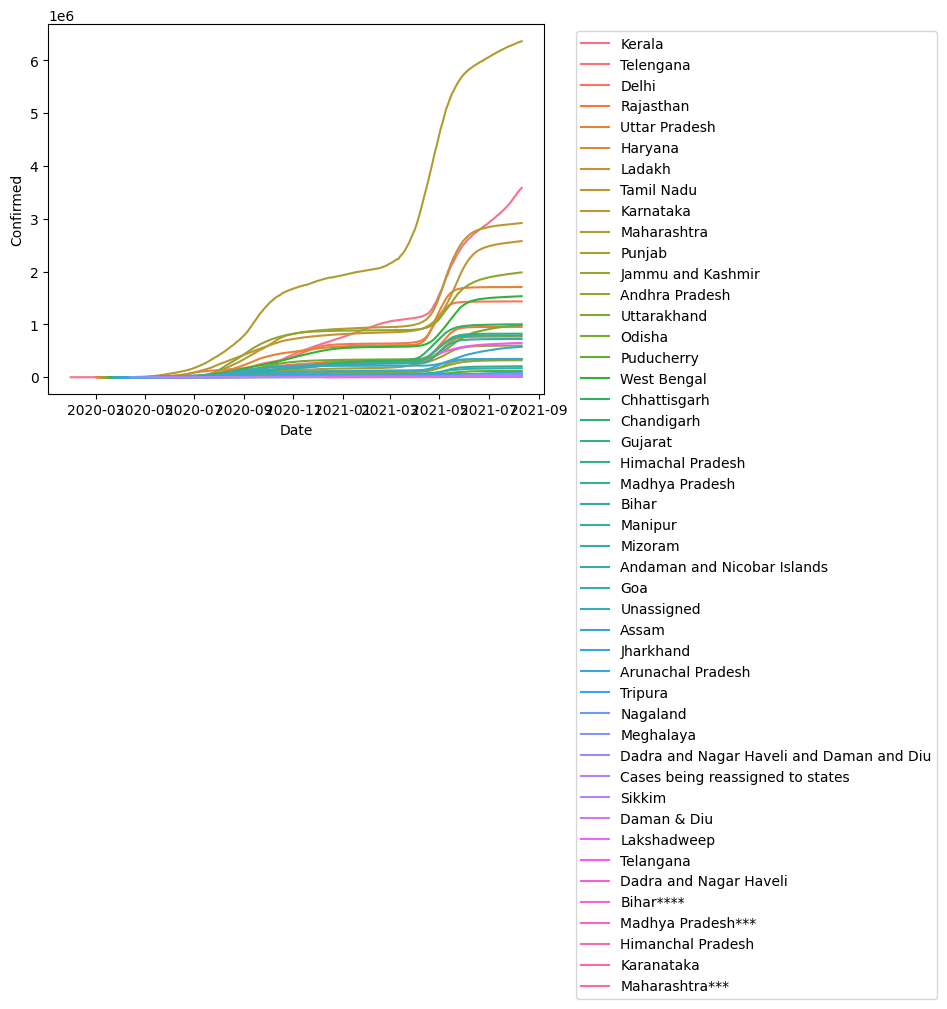

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your lineplot
sns.lineplot(data=covid_data, x='Date', y='Confirmed', hue='State')

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust the layout so everything fits
plt.tight_layout()

# Show the plot
plt.show()

<Axes: xlabel='Date', ylabel='Total Individuals Vaccinated'>

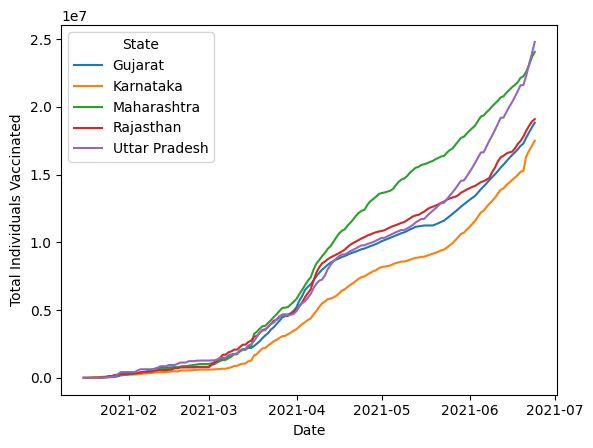

In [ ]:
# Get the top 6 states by max vaccinated individuals, then exclude the first (top) one
top_states = vaccine_data.groupby('State')['Total Individuals Vaccinated'] \
                         .max() \
                         .nlargest(6) \
                         .iloc[1:] \
                         .index

# Plot the vaccination trends for these states
sns.lineplot(
    data=vaccine_data[vaccine_data['State'].isin(top_states)],
    x='Date',
    y='Total Individuals Vaccinated',
    hue='State'
)

In [ ]:
import plotly.express as px

fig = px.scatter(
    testing_data,
    x='TotalSamples',
    y='Positive',
    color='State',
    title='COVID Testing by State'
)

# Automatically scrollable when legend has many items
fig.update_layout(legend=dict(orientation="h", y=-0.3))  # Legend below
fig.show()

<Axes: >

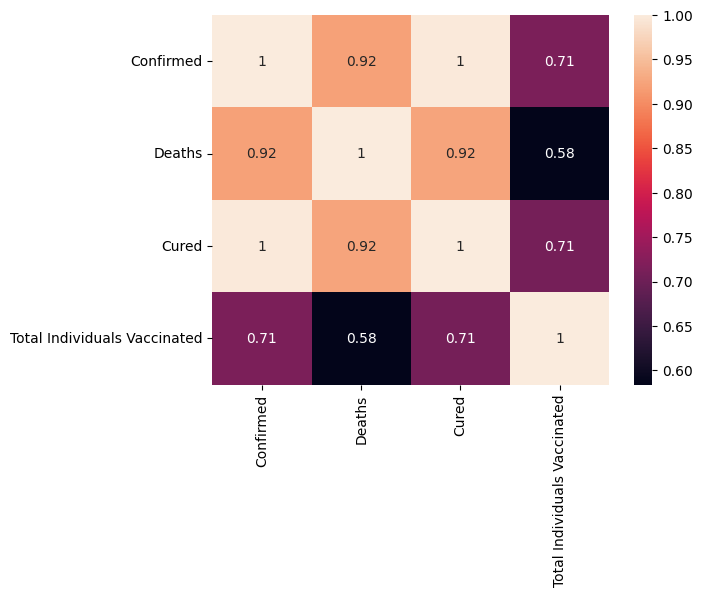

In [ ]:
merged = pd.merge(covid_data, vaccine_data, on=['Date', 'State'], how='inner')
sns.heatmap(merged[['Confirmed', 'Deaths', 'Cured', 'Total Individuals Vaccinated']].corr(), annot=True)
